# Cyber Threat Detection Machine Learning Project

We'll use different classification techniques to predict Cyber Threat

# Data preparation and Data Cleaning

*   Download the data, read it with pandas
*   Analyse the data
*   Make column names look uniform in lowercase with uderscore separating multiple words
*   Check for missing values
*   Check for numerical and categorical features
*   Perform One hot encoding for categorical features
*   Check for duplicate values and clean the data



In [28]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [13]:
# Load the dataset
cyber_data = pd.read_csv('cyberfeddefender_dataset.csv')

In [14]:
cyber_data.head()

,Timestamp,Source_IP,Destination_IP,Protocol,Packet_Length,Duration,Source_Port,Destination_Port,Bytes_Sent,Bytes_Received,...,Avg_Packet_Size,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Header_Length,Bwd_Header_Length,Sub_Flow_Fwd_Bytes,Sub_Flow_Bwd_Bytes,Inbound,Attack_Type,Label
0,10/23/2024 12:00,192.168.0.1,192.168.0.1,ICMP,1155,4.01,53,53,675,877,...,512,21,34,256,256,697,1028,1,DDoS,1
1,10/23/2024 12:00,192.168.0.7,172.16.0.5,ICMP,1776,3.75,22,22,297,1062,...,1024,14,19,512,256,513,1300,1,DDoS,1
2,10/23/2024 12:00,192.168.0.7,10.0.0.3,UDP,627,4.24,80,8080,122,723,...,512,10,41,512,256,250,497,0,DDoS,1
3,10/23/2024 12:00,192.168.0.7,10.0.0.3,UDP,1754,3.09,443,443,1626,1703,...,256,37,44,128,256,985,1471,0,Ransomware,0
4,10/23/2024 12:00,192.168.0.1,10.0.0.4,UDP,1326,2.52,80,443,1851,771,...,1024,40,16,512,256,1877,595,1,Normal,1


In [15]:
cyber_data.columns

Index(['Timestamp', 'Source_IP', 'Destination_IP', 'Protocol', 'Packet_Length',
       'Duration', 'Source_Port', 'Destination_Port', 'Bytes_Sent',
       'Bytes_Received', 'Flags', 'Flow_Packets/s', 'Flow_Bytes/s',
       'Avg_Packet_Size', 'Total_Fwd_Packets', 'Total_Bwd_Packets',
       'Fwd_Header_Length', 'Bwd_Header_Length', 'Sub_Flow_Fwd_Bytes',
       'Sub_Flow_Bwd_Bytes', 'Inbound', 'Attack_Type', 'Label'],
      dtype='object')

In [16]:
cyber_data.columns = cyber_data.columns.str.lower().str.replace(' ', '_')

In [17]:
cyber_data.head(20)

,timestamp,source_ip,destination_ip,protocol,packet_length,duration,source_port,destination_port,bytes_sent,bytes_received,...,avg_packet_size,total_fwd_packets,total_bwd_packets,fwd_header_length,bwd_header_length,sub_flow_fwd_bytes,sub_flow_bwd_bytes,inbound,attack_type,label
0,10/23/2024 12:00,192.168.0.1,192.168.0.1,ICMP,1155,4.01,53,53,675,877,...,512,21,34,256,256,697,1028,1,DDoS,1
1,10/23/2024 12:00,192.168.0.7,172.16.0.5,ICMP,1776,3.75,22,22,297,1062,...,1024,14,19,512,256,513,1300,1,DDoS,1
2,10/23/2024 12:00,192.168.0.7,10.0.0.3,UDP,627,4.24,80,8080,122,723,...,512,10,41,512,256,250,497,0,DDoS,1
3,10/23/2024 12:00,192.168.0.7,10.0.0.3,UDP,1754,3.09,443,443,1626,1703,...,256,37,44,128,256,985,1471,0,Ransomware,0
4,10/23/2024 12:00,192.168.0.1,10.0.0.4,UDP,1326,2.52,80,443,1851,771,...,1024,40,16,512,256,1877,595,1,Normal,1
5,10/23/2024 12:00,192.168.0.1,10.0.0.3,ICMP,1882,3.99,443,22,969,2038,...,1024,49,47,128,128,1171,420,0,DDoS,0
6,10/23/2024 12:00,10.0.0.9,10.0.0.3,UDP,560,0.69,80,443,1797,1408,...,1024,26,17,256,256,1241,487,0,Brute Force,0
7,10/23/2024 12:00,172.16.0.4,172.16.0.5,TCP,501,0.46,80,22,1699,1398,...,512,29,33,128,256,2042,145,0,DDoS,1
8,10/23/2024 12:00,172.16.0.3,172.16.0.5,TCP,1275,4.97,8080,22,1730,246,...,64,12,30,128,512,1357,1582,1,DDoS,1
9,10/23/2024 12:00,10.0.0.6,172.16.0.5,ICMP,1459,0.95,8080,443,1123,1529,...,64,12,12,512,256,1265,735,1,Brute Force,1


In [18]:
# Check for missing values
print(cyber_data.isnull().sum())

timestamp             0
source_ip             0
destination_ip        0
protocol              0
packet_length         0
duration              0
source_port           0
destination_port      0
bytes_sent            0
bytes_received        0
flags                 0
flow_packets/s        0
flow_bytes/s          3
avg_packet_size       0
total_fwd_packets     0
total_bwd_packets     0
fwd_header_length     0
bwd_header_length     0
sub_flow_fwd_bytes    0
sub_flow_bwd_bytes    0
inbound               0
attack_type           0
label                 0
dtype: int64


In [19]:
print(cyber_data.dtypes)

timestamp              object
source_ip              object
destination_ip         object
protocol               object
packet_length           int64
duration              float64
source_port             int64
destination_port        int64
bytes_sent              int64
bytes_received          int64
flags                  object
flow_packets/s        float64
flow_bytes/s          float64
avg_packet_size         int64
total_fwd_packets       int64
total_bwd_packets       int64
fwd_header_length       int64
bwd_header_length       int64
sub_flow_fwd_bytes      int64
sub_flow_bwd_bytes      int64
inbound                 int64
attack_type            object
label                   int64
dtype: object


In [20]:
# Impute missing values (if any) with median for numerical features - In this case - flow_bytes/s
imputer = SimpleImputer(strategy='median')
cyber_data[['flow_bytes/s']] = imputer.fit_transform(cyber_data[['flow_bytes/s']])

In [21]:
print(cyber_data.isnull().sum())

timestamp             0
source_ip             0
destination_ip        0
protocol              0
packet_length         0
duration              0
source_port           0
destination_port      0
bytes_sent            0
bytes_received        0
flags                 0
flow_packets/s        0
flow_bytes/s          0
avg_packet_size       0
total_fwd_packets     0
total_bwd_packets     0
fwd_header_length     0
bwd_header_length     0
sub_flow_fwd_bytes    0
sub_flow_bwd_bytes    0
inbound               0
attack_type           0
label                 0
dtype: int64


# Encoding IP Address Features

*   source_ip
*   destination_ip



In [26]:
#Checking the count of unique source_ip and destination_ip
unique_source_ips = cyber_data['source_ip'].nunique()
unique_destination_ips = cyber_data['destination_ip'].nunique()
print(f"Number of unique source IPs: {unique_source_ips}")
print(f"Number of unique destination IPs: {unique_destination_ips}")

Number of unique source IPs: 9
Number of unique destination IPs: 6


In [32]:
# Apply Label Encoding
encoder = LabelEncoder()
cyber_data['source_ip_encoded'] = encoder.fit_transform(cyber_data['source_ip'])
cyber_data['destination_ip_encoded'] = encoder.fit_transform(cyber_data['destination_ip'])
cyber_data.drop(columns=['source_ip', 'destination_ip'], inplace=True)

In [33]:
cyber_data.head()

,timestamp,protocol,packet_length,duration,source_port,destination_port,bytes_sent,bytes_received,flags,flow_packets/s,...,total_bwd_packets,fwd_header_length,bwd_header_length,sub_flow_fwd_bytes,sub_flow_bwd_bytes,inbound,attack_type,label,source_ip_encoded,destination_ip_encoded
0,10/23/2024 12:00,ICMP,1155,4.01,53,53,675,877,SYN,37.9,...,34,256,256,697,1028,1,DDoS,1,6,4
1,10/23/2024 12:00,ICMP,1776,3.75,22,22,297,1062,ACK,37.8,...,19,512,256,513,1300,1,DDoS,1,7,3
2,10/23/2024 12:00,UDP,627,4.24,80,8080,122,723,ACK,12.3,...,41,512,256,250,497,0,DDoS,1,7,0
3,10/23/2024 12:00,UDP,1754,3.09,443,443,1626,1703,FIN,19.2,...,44,128,256,985,1471,0,Ransomware,0,7,0
4,10/23/2024 12:00,UDP,1326,2.52,80,443,1851,771,PSH,16.2,...,16,512,256,1877,595,1,Normal,1,6,1


In [34]:
# Convert 'timestamp' to datetime
cyber_data['timestamp'] = pd.to_datetime(cyber_data['timestamp'])

# Extract time-based features
cyber_data['year'] = cyber_data['timestamp'].dt.year
cyber_data['month'] = cyber_data['timestamp'].dt.month
cyber_data['day'] = cyber_data['timestamp'].dt.day
cyber_data['hour'] = cyber_data['timestamp'].dt.hour
cyber_data['minute'] = cyber_data['timestamp'].dt.minute

# Drop the original 'timestamp' column
cyber_data.drop(columns=['timestamp'], inplace=True)

In [35]:
cyber_data.head()

,protocol,packet_length,duration,source_port,destination_port,bytes_sent,bytes_received,flags,flow_packets/s,flow_bytes/s,...,inbound,attack_type,label,source_ip_encoded,destination_ip_encoded,year,month,day,hour,minute
0,ICMP,1155,4.01,53,53,675,877,SYN,37.9,583.2,...,1,DDoS,1,6,4,2024,10,23,12,0
1,ICMP,1776,3.75,22,22,297,1062,ACK,37.8,1100.6,...,1,DDoS,1,7,3,2024,10,23,12,0
2,UDP,627,4.24,80,8080,122,723,ACK,12.3,339.1,...,0,DDoS,1,7,0,2024,10,23,12,0
3,UDP,1754,3.09,443,443,1626,1703,FIN,19.2,1913.5,...,0,Ransomware,0,7,0,2024,10,23,12,0
4,UDP,1326,2.52,80,443,1851,771,PSH,16.2,105.9,...,1,Normal,1,6,1,2024,10,23,12,0


In [36]:
# Apply OneHotEncoding to categorical columns - 'Protocol','Flags' and 'Attack_Type'
encoder = OneHotEncoder(sparse_output=False)
categorical_cols = ['protocol', 'flags', 'attack_type']  # Example categorical columns
encoded_cols = encoder.fit_transform(cyber_data[categorical_cols])

In [37]:
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(categorical_cols))

In [38]:
# Concatenate the encoded columns
cyber_data = cyber_data.drop(columns=categorical_cols)
cyber_data = pd.concat([cyber_data, encoded_df], axis=1)

In [39]:
# Print the cleaned & categorically encoded data
print(cyber_data.head())

   packet_length  duration  source_port  destination_port  bytes_sent  \
0           1155      4.01           53                53         675   
1           1776      3.75           22                22         297   
2            627      4.24           80              8080         122   
3           1754      3.09          443               443        1626   
4           1326      2.52           80               443        1851   

   bytes_received  flow_packets/s  flow_bytes/s  avg_packet_size  \
0             877            37.9         583.2              512   
1            1062            37.8        1100.6             1024   
2             723            12.3         339.1              512   
3            1703            19.2        1913.5              256   
4             771            16.2         105.9             1024   

   total_fwd_packets  ...  protocol_TCP  protocol_UDP  flags_ACK  flags_FIN  \
0                 21  ...           0.0           0.0        0.0        0

In [40]:
cyber_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   packet_length            1430 non-null   int64  
 1   duration                 1430 non-null   float64
 2   source_port              1430 non-null   int64  
 3   destination_port         1430 non-null   int64  
 4   bytes_sent               1430 non-null   int64  
 5   bytes_received           1430 non-null   int64  
 6   flow_packets/s           1430 non-null   float64
 7   flow_bytes/s             1430 non-null   float64
 8   avg_packet_size          1430 non-null   int64  
 9   total_fwd_packets        1430 non-null   int64  
 10  total_bwd_packets        1430 non-null   int64  
 11  fwd_header_length        1430 non-null   int64  
 12  bwd_header_length        1430 non-null   int64  
 13  sub_flow_fwd_bytes       1430 non-null   int64  
 14  sub_flow_bwd_bytes      

In [41]:
# Check for duplicates in the data and remove them
cyber_data.drop_duplicates(inplace=True)

In [42]:
cyber_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   packet_length            1430 non-null   int64  
 1   duration                 1430 non-null   float64
 2   source_port              1430 non-null   int64  
 3   destination_port         1430 non-null   int64  
 4   bytes_sent               1430 non-null   int64  
 5   bytes_received           1430 non-null   int64  
 6   flow_packets/s           1430 non-null   float64
 7   flow_bytes/s             1430 non-null   float64
 8   avg_packet_size          1430 non-null   int64  
 9   total_fwd_packets        1430 non-null   int64  
 10  total_bwd_packets        1430 non-null   int64  
 11  fwd_header_length        1430 non-null   int64  
 12  bwd_header_length        1430 non-null   int64  
 13  sub_flow_fwd_bytes       1430 non-null   int64  
 14  sub_flow_bwd_bytes      

# Exploratory Data Analysis (EDA) and Feature Importance Analysis

In [43]:
# Use describe() to explore descriptive statistics of data
print(cyber_data.describe())

       packet_length     duration  source_port  destination_port   bytes_sent  \
count    1430.000000  1430.000000  1430.000000       1430.000000  1430.000000   
mean     1064.520280     2.586084  1673.184615       1848.512587  1015.900000   
std       572.437816     1.420248  3124.172914       3275.839849   569.400101   
min        64.000000     0.100000    22.000000         22.000000    65.000000   
25%       562.000000     1.360000    53.000000         53.000000   503.000000   
50%      1066.000000     2.605000    80.000000         80.000000  1019.000000   
75%      1539.000000     3.840000   443.000000        443.000000  1497.000000   
max      2046.000000     5.000000  8080.000000       8080.000000  2045.000000   

       bytes_received  flow_packets/s  flow_bytes/s  avg_packet_size  \
count     1430.000000     1430.000000   1430.000000      1430.000000   
mean      1045.531469       24.793007   1070.834895       460.128671   
std        572.170268        8.772747    561.656986   

In [44]:
#Drop the timestamp column since it’s not directly related to identifying the type of cyber attack (as we aren't focusing on attacks over time).
cyber_data.columns
#cyber_data = cyber_data.drop(columns=['timestamp','source_ip','destination_ip','source_port','destination_port'])

Index(['packet_length', 'duration', 'source_port', 'destination_port',
       'bytes_sent', 'bytes_received', 'flow_packets/s', 'flow_bytes/s',
       'avg_packet_size', 'total_fwd_packets', 'total_bwd_packets',
       'fwd_header_length', 'bwd_header_length', 'sub_flow_fwd_bytes',
       'sub_flow_bwd_bytes', 'inbound', 'label', 'source_ip_encoded',
       'destination_ip_encoded', 'year', 'month', 'day', 'hour', 'minute',
       'protocol_ICMP', 'protocol_TCP', 'protocol_UDP', 'flags_ACK',
       'flags_FIN', 'flags_PSH', 'flags_SYN', 'attack_type_Brute Force',
       'attack_type_DDoS', 'attack_type_Normal', 'attack_type_Ransomware'],
      dtype='object')

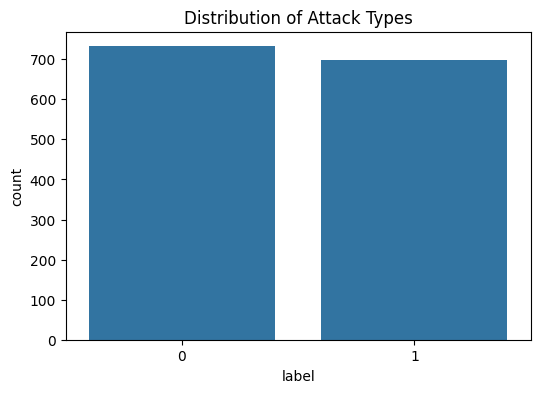

In [45]:
# Check the distribution of the target variable
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=cyber_data)
plt.title('Distribution of Attack Types')
plt.show()

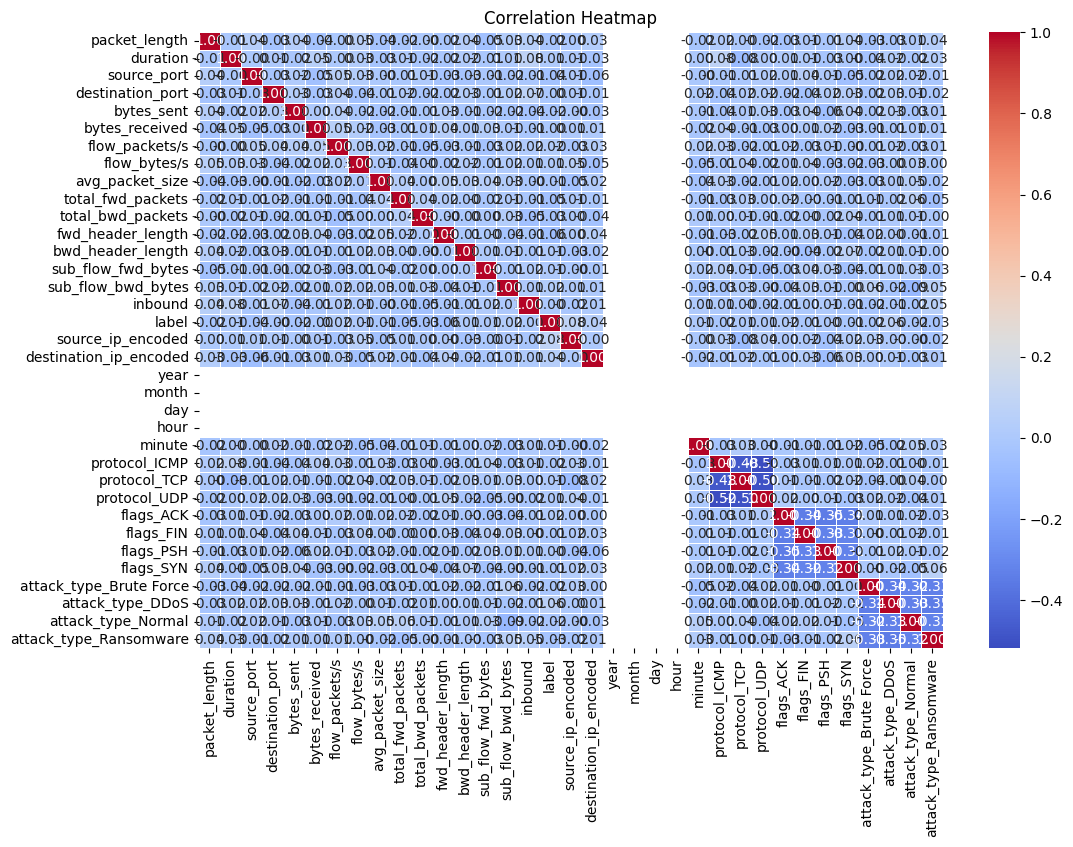

In [46]:
# Correlation heatmap to explore relationships between features
plt.figure(figsize=(12, 8))
sns.heatmap(cyber_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [47]:
# Pair plot
sns.pairplot(cyber_data, hue='label')
plt.show()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7afc688411b0> (for post_execute):


KeyboardInterrupt: 

# Feature importance analysis using RandomForestClassifier

In [48]:
# Prepare features and target variable
X = cyber_data.drop(columns=['label'])
y = cyber_data['label']

In [49]:
# Train a RandomForest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

RandomForestClassifier(random_state=42)

In [50]:
# Plot feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print(feature_importances)

sub_flow_bwd_bytes         0.071233
flow_packets/s             0.068989
flow_bytes/s               0.066797
packet_length              0.066292
duration                   0.065917
sub_flow_fwd_bytes         0.065696
bytes_sent                 0.065305
bytes_received             0.063309
total_fwd_packets          0.061022
total_bwd_packets          0.054058
minute                     0.053925
source_ip_encoded          0.039317
source_port                0.028651
destination_ip_encoded     0.028336
destination_port           0.025611
avg_packet_size            0.023487
fwd_header_length          0.018911
bwd_header_length          0.018731
attack_type_DDoS           0.010542
inbound                    0.010397
attack_type_Normal         0.010119
flags_PSH                  0.009848
protocol_ICMP              0.009718
attack_type_Ransomware     0.009517
protocol_TCP               0.009501
flags_ACK                  0.009443
protocol_UDP               0.009348
flags_SYN                  0

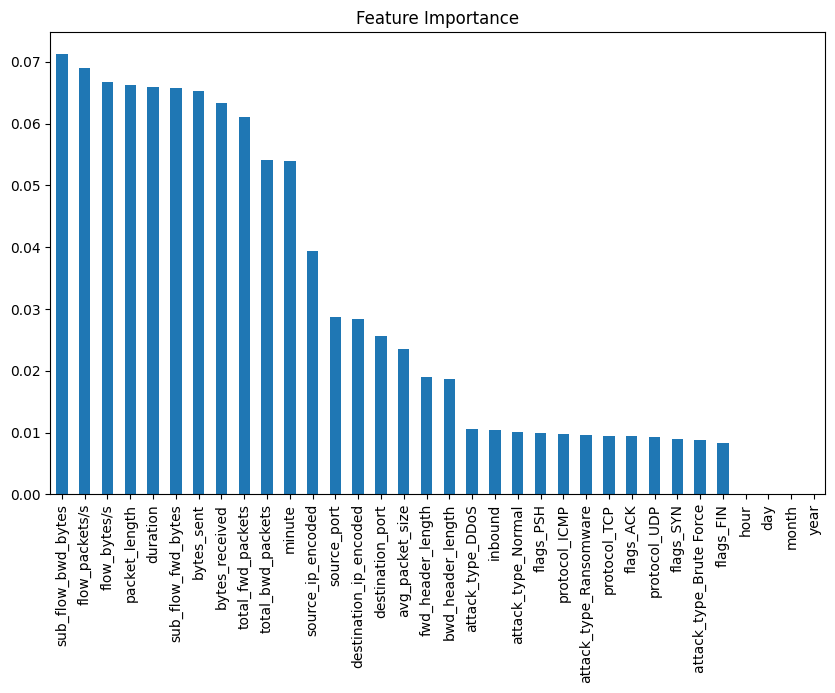

In [51]:
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.title('Feature Importance')
plt.show()

# Model Selection and Parameter Tuning

In [52]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
# Create a dictionary of models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Classifier': SVC()
}

In [54]:
# Function to evaluate models
def evaluate_models(models, X_train, X_test, y_train, y_test):
    results = {}
    for name, model in models.items():
        #model.fit(X_train, y_train)
        pipeline = make_pipeline(StandardScaler(), model)
        # Fit the model
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred)
        results[name] = {'accuracy': accuracy, 'classification_report': report}
    return results

In [55]:
# Evaluate all models
results = evaluate_models(models, X_train, X_test, y_train, y_test)

In [56]:
# Display the results
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"Accuracy: {metrics['accuracy']}")
    print(f"Classification Report: \n{metrics['classification_report']}")
    print("\n")

Model: Logistic Regression
Accuracy: 0.527972027972028
Classification Report: 
              precision    recall  f1-score   support

           0       0.52      0.61      0.56       140
           1       0.55      0.45      0.49       146

    accuracy                           0.53       286
   macro avg       0.53      0.53      0.53       286
weighted avg       0.53      0.53      0.53       286



Model: Random Forest
Accuracy: 0.5209790209790209
Classification Report: 
              precision    recall  f1-score   support

           0       0.51      0.67      0.58       140
           1       0.54      0.38      0.45       146

    accuracy                           0.52       286
   macro avg       0.53      0.52      0.51       286
weighted avg       0.53      0.52      0.51       286



Model: Support Vector Classifier
Accuracy: 0.527972027972028
Classification Report: 
              precision    recall  f1-score   support

           0       0.51      0.62      0.56      